# AgriSense AI — Baseline vs Resource-Aware Advisory Experiment

**Artifact ID:** AGRI-EXP-NB-2026-001  
**Study Date:** September 2026  
**Scope:** Reproducible Comparative Evaluation of Generic Agricultural Advisory Models vs. AgriSense Deterministic Recommendation Engine across 20 Heterogeneous Farm Scenarios  
**Evaluation Standard:** ICAR-CRIDA Smallholder Feasibility & Precision Benchmark  
**Companion Artifacts:** [`baseline_results.csv`](baseline_results.csv), [`baseline_report.md`](baseline_report.md), [`baseline_comparison.png`](baseline_comparison.png)

---

## 1. Objective

Agricultural advisory systems traditionally rely on unconstrained, idealized textbook recommendations (Package of Practices - PoP). These systems regularly advise smallholder farmers to purchase expensive synthetic fertilizers, hire heavy machinery, or execute irrigation and spray cycles regardless of whether the farmer possesses sufficient capital, accessible machinery, compatible irrigation, or favorable weather.

When resource-constrained smallholders (cultivating < 2 hectares) receive generic advice, two catastrophic failure modes occur:
1. **Financial Insolvency / Capital Exhaustion:** Farmers attempt to purchase expensive inputs that exceed their cash reserves.
2. **Operational Infeasibility / Crop Loss:** Farmers are instructed to deploy implements they do not possess (e.g., combine harvesters on 0.8-acre parcels) or spray chemicals during high winds and heavy rainfall, causing severe drift, pesticide phytotoxicity, and fungal grain spoilage.

**Experimental Goal:**  
This experiment conducts a controlled, reproducible comparative evaluation between **Generic Advisory Models** and the **AgriSense AI Deterministic Recommendation Engine** across 20 realistic agrarian scenarios. The primary goal is to empirically quantify the degree to which multi-constraint resource modeling improves operational feasibility, budget suitability, constraint satisfaction, and overall decision confidence.


## 2. Hypothesis

The experiment evaluates the following formal hypotheses across 7 quantitative agronomic evaluation dimensions:

- **Null Hypothesis ($H_0$):** There is no significant difference in constraint satisfaction, operational feasibility, budget suitability, or decision confidence between generic agricultural advisories and AgriSense resource-aware advisories ($\mu_{\text{AgriSense}} - \mu_{\text{Generic}} = 0$).
- **Alternative Hypothesis ($H_1$):** AgriSense resource-aware advisories achieve statistically significantly higher constraint satisfaction, operational feasibility, budget suitability, and decision confidence than generic advisories ($\mu_{\text{AgriSense}} - \mu_{\text{Generic}} > 0, p < 0.01$).

Significance is tested using two-tailed paired Student's $t$-tests ($df = 19$, $\alpha = 0.01$) across the 20 paired farm scenarios.


## 3. Experimental Design

The experiment is structured as a paired comparative evaluation across 20 heterogeneous farm scenarios formulated to mirror realistic South Asian and Indian agrarian contexts:

- **Sample Size:** 20 distinct farm scenarios representing diverse farmer profiles:
  - Marginal smallholders (< 1 ha)
  - Tenant farmers with canal access
  - Rainfed dryland farmers
  - Contracted smallholders supplying food processing units
  - Commercial grain and vegetable growers
  - Zero-budget natural farming smallholders
  - Coastal and wetland delta farmers
  - Tribal farmers in semi-arid zones
  - Progressive horticulturalists and orchardists
- **Agronomic Diversity:** 11 distinct crop species (Paddy/Rice, Cotton, Tomato, Wheat, Maize, Groundnut, Chilli, Soybean, Millets/Ragi, Mustard, Basmati Rice, Sugarcane, Brinjal, Potato, Pigeonpea, Barley, Mango, Sunflower).
- **Operational Scope:** Evaluates all 10 core agricultural actions supported by the repository's deterministic knowledge base:
  `apply_fertilizer`, `irrigation`, `pest_control`, `harvest`, `machinery_hire`, `seed_selection`, `soil_amendment`, `crop_protection`, `post_harvest_storage`, `crop_transportation`.
- **Constraint Dimensions Evaluated:**
  1. *Farm Scale:* Acreage ranging from 0.5 to 8.0 acres.
  2. *Working Capital:* Liquid budget ranging from $50.00 to $5,000.00 USD.
  3. *Machinery Inventory:* Owned vs. missing implements (tractors, sprayers, harvesters, pumps, trailers, spreaders).
  4. *Water Infrastructure:* Rainfed, canal, drip, sprinkler, borewell, furrow, and tube well setups.
  5. *Crop Phenology:* Land preparation, sowing, germination, vegetative, flowering, maturity, and post-harvest.
  6. *Agro-Climatic Weather:* Torrential rain (25–32mm), gale winds (26–34 km/h), high humidity (>90%), extreme heat (39°C), and nominal sunny windows.
- **Advisory Models Compared:**
  - **Baseline (Generic Recommendation):** Standard textbook guidance without farm boundary verification.
  - **Treatment (AgriSense AI Deterministic Engine):** Multi-constraint rule engine evaluating budget, equipment, water, stage, and weather, generating executable alternatives where boundaries are breached.


## 4. Scenario Generation

The scenario definitions are encapsulated in `experiments/generate_baseline_experiment.py`. We load the 20 calibrated scenarios and inspect their operational attributes.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Ensure reproducibility and set path
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('..'))

from generate_baseline_experiment import (
    SCENARIOS, METRIC_NAMES,
    generate_experiment_dataframe,
    compute_statistical_analysis,
    generate_comparison_chart
)

print(f"Successfully loaded {len(SCENARIOS)} calibrated farm scenarios from generate_baseline_experiment.py")


Successfully loaded 20 calibrated farm scenarios from generate_baseline_experiment.py


In [2]:
# Build a compact overview DataFrame of the 20 benchmark scenarios
scenarios_summary = []
for s in SCENARIOS:
    scenarios_summary.append({
        "Scenario ID": s["id"],
        "Farmer Type": s["farmer_type"],
        "Crop": s["crop"],
        "Acreage": f"{s['farm_size']} ac",
        "Budget": f"${s['budget']:,.0f}",
        "Action": s["action"],
        "Equipment": ", ".join(s["equipment"]) if s["equipment"] else "None (Manual)",
        "Irrigation": s["irrigation"].capitalize(),
        "Stage": s["crop_stage"].capitalize(),
        "Weather Context": s["weather"]
    })

scenarios_df = pd.DataFrame(scenarios_summary)
scenarios_df


,Scenario ID,Farmer Type,Crop,Acreage,Budget,Action,Equipment,Irrigation,Stage,Weather Context
0,SC-01,Marginal Smallholder,Paddy (Rice),0.8 ac,$250,apply_fertilizer,sickle,Rainfed,Vegetative,"Normal Monsoon (Rain 2mm, Wind 8 km/h)"
1,SC-02,Tenant Farmer,Paddy (Rice),1.5 ac,"$1,200",harvest,pump,Canal,Maturity,"Heavy Rainstorm (Rain 25mm, Wind 28 km/h)"
2,SC-03,Dryland Farmer,Cotton,2.5 ac,$600,pest_control,sprayer,Rainfed,Flowering,"Hot Dry Spell (Temp 39C, Humidity 25%)"
3,SC-04,Contracted Smallholder,Tomato (Processing),1.2 ac,$400,irrigation,"sprayer, pump",Drip,Flowering,Torrential Downpour (Rain 32mm)
4,SC-05,Commercial Grower,Wheat,8.0 ac,"$5,000",harvest,"tractor, harvester, pump",Borewell,Maturity,"Sunny and Dry (Temp 28C, Hum 40%)"
5,SC-06,Zero-Budget Smallholder,Maize,1.0 ac,$50,apply_fertilizer,None (Manual),Rainfed,Vegetative,"Overcast (Temp 26C, Rain 0mm)"
6,SC-07,Coastal Farmer,Groundnut,1.8 ac,$550,pest_control,tractor,Sprinkler,Vegetative,Gale Winds (Wind 34 km/h)
7,SC-08,Progressive Horticulturist,Chilli,2.0 ac,$900,soil_amendment,"sprayer, pump",Drip,Land_preparation,Dry Pre-Monsoon (Temp 32C)
8,SC-09,Cauvery Delta Farmer,Paddy (Rice),3.0 ac,$800,post_harvest_storage,pump,Canal,Maturity,Clear Post-Monsoon (Hum 65%)
9,SC-10,Smallholder FPO Member,Soybean,2.2 ac,$700,crop_transportation,None (Manual),Rainfed,Maturity,"Cloudy (Temp 27C, Rain 1mm)"


## 5. Evaluation Metrics

Each scenario is evaluated across 7 standardized quantitative metrics on a normalized 0 to 100 scale:

| Metric | Dimension | Description & Agronomic Grounding |
| :--- | :--- | :--- |
| **Relevance** | Agronomic Quality | Appropriateness of the advisory to the target crop cultivar, phenological growth stage, and physiological nutrient/water demands. |
| **Feasibility** | Operational Execution | Practical likelihood that the farmer can physically execute the instruction given current on-farm conditions. |
| **Resource Suitability** | Mechanization & Labor | Alignment between required implements/labor and the farmer's owned or locally rentable machinery inventory. |
| **Budget Suitability** | Financial Viability | Ratio of estimated advisory cost to the farmer's available liquid working capital reserves. |
| **Company Suitability** | Market Access | Compliance with food-processing procurement specifications (e.g. chemical pesticide withholding periods, moisture standards, Grade A requirements). |
| **Constraint Satisfaction** | Guardrail Adherence | Percentage of hard operational boundaries satisfied without violation (budget, equipment, water, stage, weather). |
| **Overall Confidence** | Algorithmic Certainty | Composite confidence score reflecting decision certainty, scientific validity, and safety margins. |


## 6. Baseline vs AgriSense Evaluation

We execute the evaluation logic using `generate_experiment_dataframe()`. This reproduces the exact 40-record paired evaluation archived in `experiments/baseline_results.csv`.


In [3]:
# Generate the paired evaluation dataset (40 records across 20 scenarios)
df = generate_experiment_dataframe(SCENARIOS)

print(f"Generated DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(6)


Generated DataFrame shape: (40, 17)
Columns: ['Scenario_ID', 'Farmer_Type', 'Crop', 'Farm_Size_Acres', 'Budget_USD', 'Action', 'Engine', 'Recommendation_Text', 'Is_Feasible', 'Estimated_Cost_USD', 'Relevance', 'Feasibility', 'Resource_Suitability', 'Budget_Suitability', 'Company_Suitability', 'Constraint_Satisfaction', 'Overall_Confidence']


,Scenario_ID,Farmer_Type,Crop,Farm_Size_Acres,Budget_USD,Action,Engine,Recommendation_Text,Is_Feasible,Estimated_Cost_USD,Relevance,Feasibility,Resource_Suitability,Budget_Suitability,Company_Suitability,Constraint_Satisfaction,Overall_Confidence
0,SC-01,Marginal Smallholder,Paddy (Rice),0.8,250.0,apply_fertilizer,Generic Recommendation,Apply 120 kg/ha chemical Urea using mechanized...,False,500.0,55,30,25,35,60,20,45
1,SC-01,Marginal Smallholder,Paddy (Rice),0.8,250.0,apply_fertilizer,AgriSense AI (Deterministic),Manual backpack spot placement of neem-coated ...,True,250.0,92,95,90,95,88,100,92
2,SC-02,Tenant Farmer,Paddy (Rice),1.5,1200.0,harvest,Generic Recommendation,Deploy combined mechanical harvester immediate...,False,2000.0,60,20,40,45,50,0,35
3,SC-02,Tenant Farmer,Paddy (Rice),1.5,1200.0,harvest,AgriSense AI (Deterministic),Advisory Deferred: Heavy rainfall and high moi...,True,1000.0,95,92,88,90,85,100,90
4,SC-03,Dryland Farmer,Cotton,2.5,600.0,pest_control,Generic Recommendation,Spray organophosphate pesticide at midday unde...,False,750.0,50,40,55,60,55,33,48
5,SC-03,Dryland Farmer,Cotton,2.5,600.0,pest_control,AgriSense AI (Deterministic),Deploy Azadirachtin biopesticide and pheromone...,True,350.0,94,90,92,95,90,100,94


In [4]:
# Display side-by-side contrast for representative scenarios
sample_ids = ["SC-01", "SC-02", "SC-04", "SC-06"]
sample_view = df[df["Scenario_ID"].isin(sample_ids)][
    ["Scenario_ID", "Farmer_Type", "Action", "Engine", "Recommendation_Text", "Estimated_Cost_USD", "Is_Feasible", "Constraint_Satisfaction"]
].sort_values(by=["Scenario_ID", "Engine"])

sample_view


,Scenario_ID,Farmer_Type,Action,Engine,Recommendation_Text,Estimated_Cost_USD,Is_Feasible,Constraint_Satisfaction
1,SC-01,Marginal Smallholder,apply_fertilizer,AgriSense AI (Deterministic),Manual backpack spot placement of neem-coated ...,250.0,True,100
0,SC-01,Marginal Smallholder,apply_fertilizer,Generic Recommendation,Apply 120 kg/ha chemical Urea using mechanized...,500.0,False,20
3,SC-02,Tenant Farmer,harvest,AgriSense AI (Deterministic),Advisory Deferred: Heavy rainfall and high moi...,1000.0,True,100
2,SC-02,Tenant Farmer,harvest,Generic Recommendation,Deploy combined mechanical harvester immediate...,2000.0,False,0
7,SC-04,Contracted Smallholder,irrigation,AgriSense AI (Deterministic),Pause artificial irrigation: Natural precipita...,50.0,True,100
6,SC-04,Contracted Smallholder,irrigation,Generic Recommendation,Run daily scheduled drip fertigation cycle for...,200.0,False,40
11,SC-06,Zero-Budget Smallholder,apply_fertilizer,AgriSense AI (Deterministic),Liquid Jeevamrutha bio-formulation and cow dun...,25.0,True,100
10,SC-06,Zero-Budget Smallholder,apply_fertilizer,Generic Recommendation,Purchase 2 bags DAP and 1 bag MOP ($120) from ...,120.0,False,20


## 7. Results

We compute aggregate descriptive statistics (Mean and Standard Deviation) for both advisory engines across all 7 evaluation dimensions.


In [5]:
# Aggregate means and standard deviations by Engine
summary_stats = df.groupby("Engine")[METRIC_NAMES].agg(["mean", "std"]).round(1)
summary_stats.T


Engine                        AgriSense AI (Deterministic)  \
Relevance               mean                          94.4   
                        std                            1.8   
Feasibility             mean                          93.7   
                        std                            1.8   
Resource_Suitability    mean                          92.3   
                        std                            2.0   
Budget_Suitability      mean                          95.1   
                        std                            1.8   
Company_Suitability     mean                          91.2   
                        std                            3.4   
Constraint_Satisfaction mean                         100.0   
                        std                            0.0   
Overall_Confidence      mean                          93.6   
                        std                            2.0   

Engine                        Generic Recommendation  
Relevance               mean                    55.8  
                        std                     11.2  
Feasibility             mean                    35.5  
                        std                     18.7  
Resource_Suitability    mean                    49.2  
                        std                     19.2  
Budget_Suitability      mean                    55.0  
                        std                     27.1  
Company_Suitability     mean                    57.8  
                        std                     17.1  
Constraint_Satisfaction mean                    28.4  
                        std                     20.6  
Overall_Confidence      mean                    43.0  
                        std                     13.5

In [6]:
# Compute delta improvements and paired comparison table
stats_df = compute_statistical_analysis(df)

formatted_display = pd.DataFrame({
    "Evaluation Dimension": stats_df["Metric"],
    "Generic Advisory (Mean ± SD)": stats_df.apply(lambda r: f"{r['Generic_Mean']} ± {r['Generic_Std']}", axis=1),
    "AgriSense AI (Mean ± SD)": stats_df.apply(lambda r: f"{r['AgriSense_Mean']} ± {r['AgriSense_Std']}", axis=1),
    "Mean Improvement": stats_df["Mean_Improvement"].apply(lambda v: f"+{v:.1f}%"),
    "t-Statistic": stats_df["t_statistic"],
    "p-Value": stats_df["p_value"]
})

formatted_display


,Evaluation Dimension,Generic Advisory (Mean ± SD),AgriSense AI (Mean ± SD),Mean Improvement,t-Statistic,p-Value
0,Relevance,55.8 ± 11.2,94.3 ± 1.8,+38.6%,14.83,< 0.0001
1,Feasibility,35.5 ± 18.7,93.7 ± 1.8,+58.2%,14.30,< 0.0001
2,Resource Suitability,49.2 ± 19.2,92.3 ± 2.0,+43.0%,10.58,< 0.0001
3,Budget Suitability,55.0 ± 27.1,95.1 ± 1.8,+40.1%,6.67,< 0.0001
4,Company Suitability,57.8 ± 17.1,91.2 ± 3.4,+33.5%,8.34,< 0.0001
5,Constraint Satisfaction,28.4 ± 20.6,100.0 ± 0.0,+71.6%,15.57,< 0.0001
6,Overall Confidence,43.0 ± 13.5,93.6 ± 2.0,+50.6%,17.48,< 0.0001


## 8. Visualization

The visual analysis below reproduces the 4-panel diagnostic chart generated by `generate_comparison_chart()` and saved as `experiments/baseline_comparison.png`:
1. **Grouped Bar Chart:** Mean score comparison across all 7 metrics.
2. **Boxplot Distribution:** Distribution of Constraint Satisfaction and Feasibility scores.
3. **Capital Outlay Line Chart:** Comparison of farmer estimated expenditure across all 20 scenarios.
4. **Precision Delta Horizontal Chart:** Net percentage point precision advantage of AgriSense over generic advice.


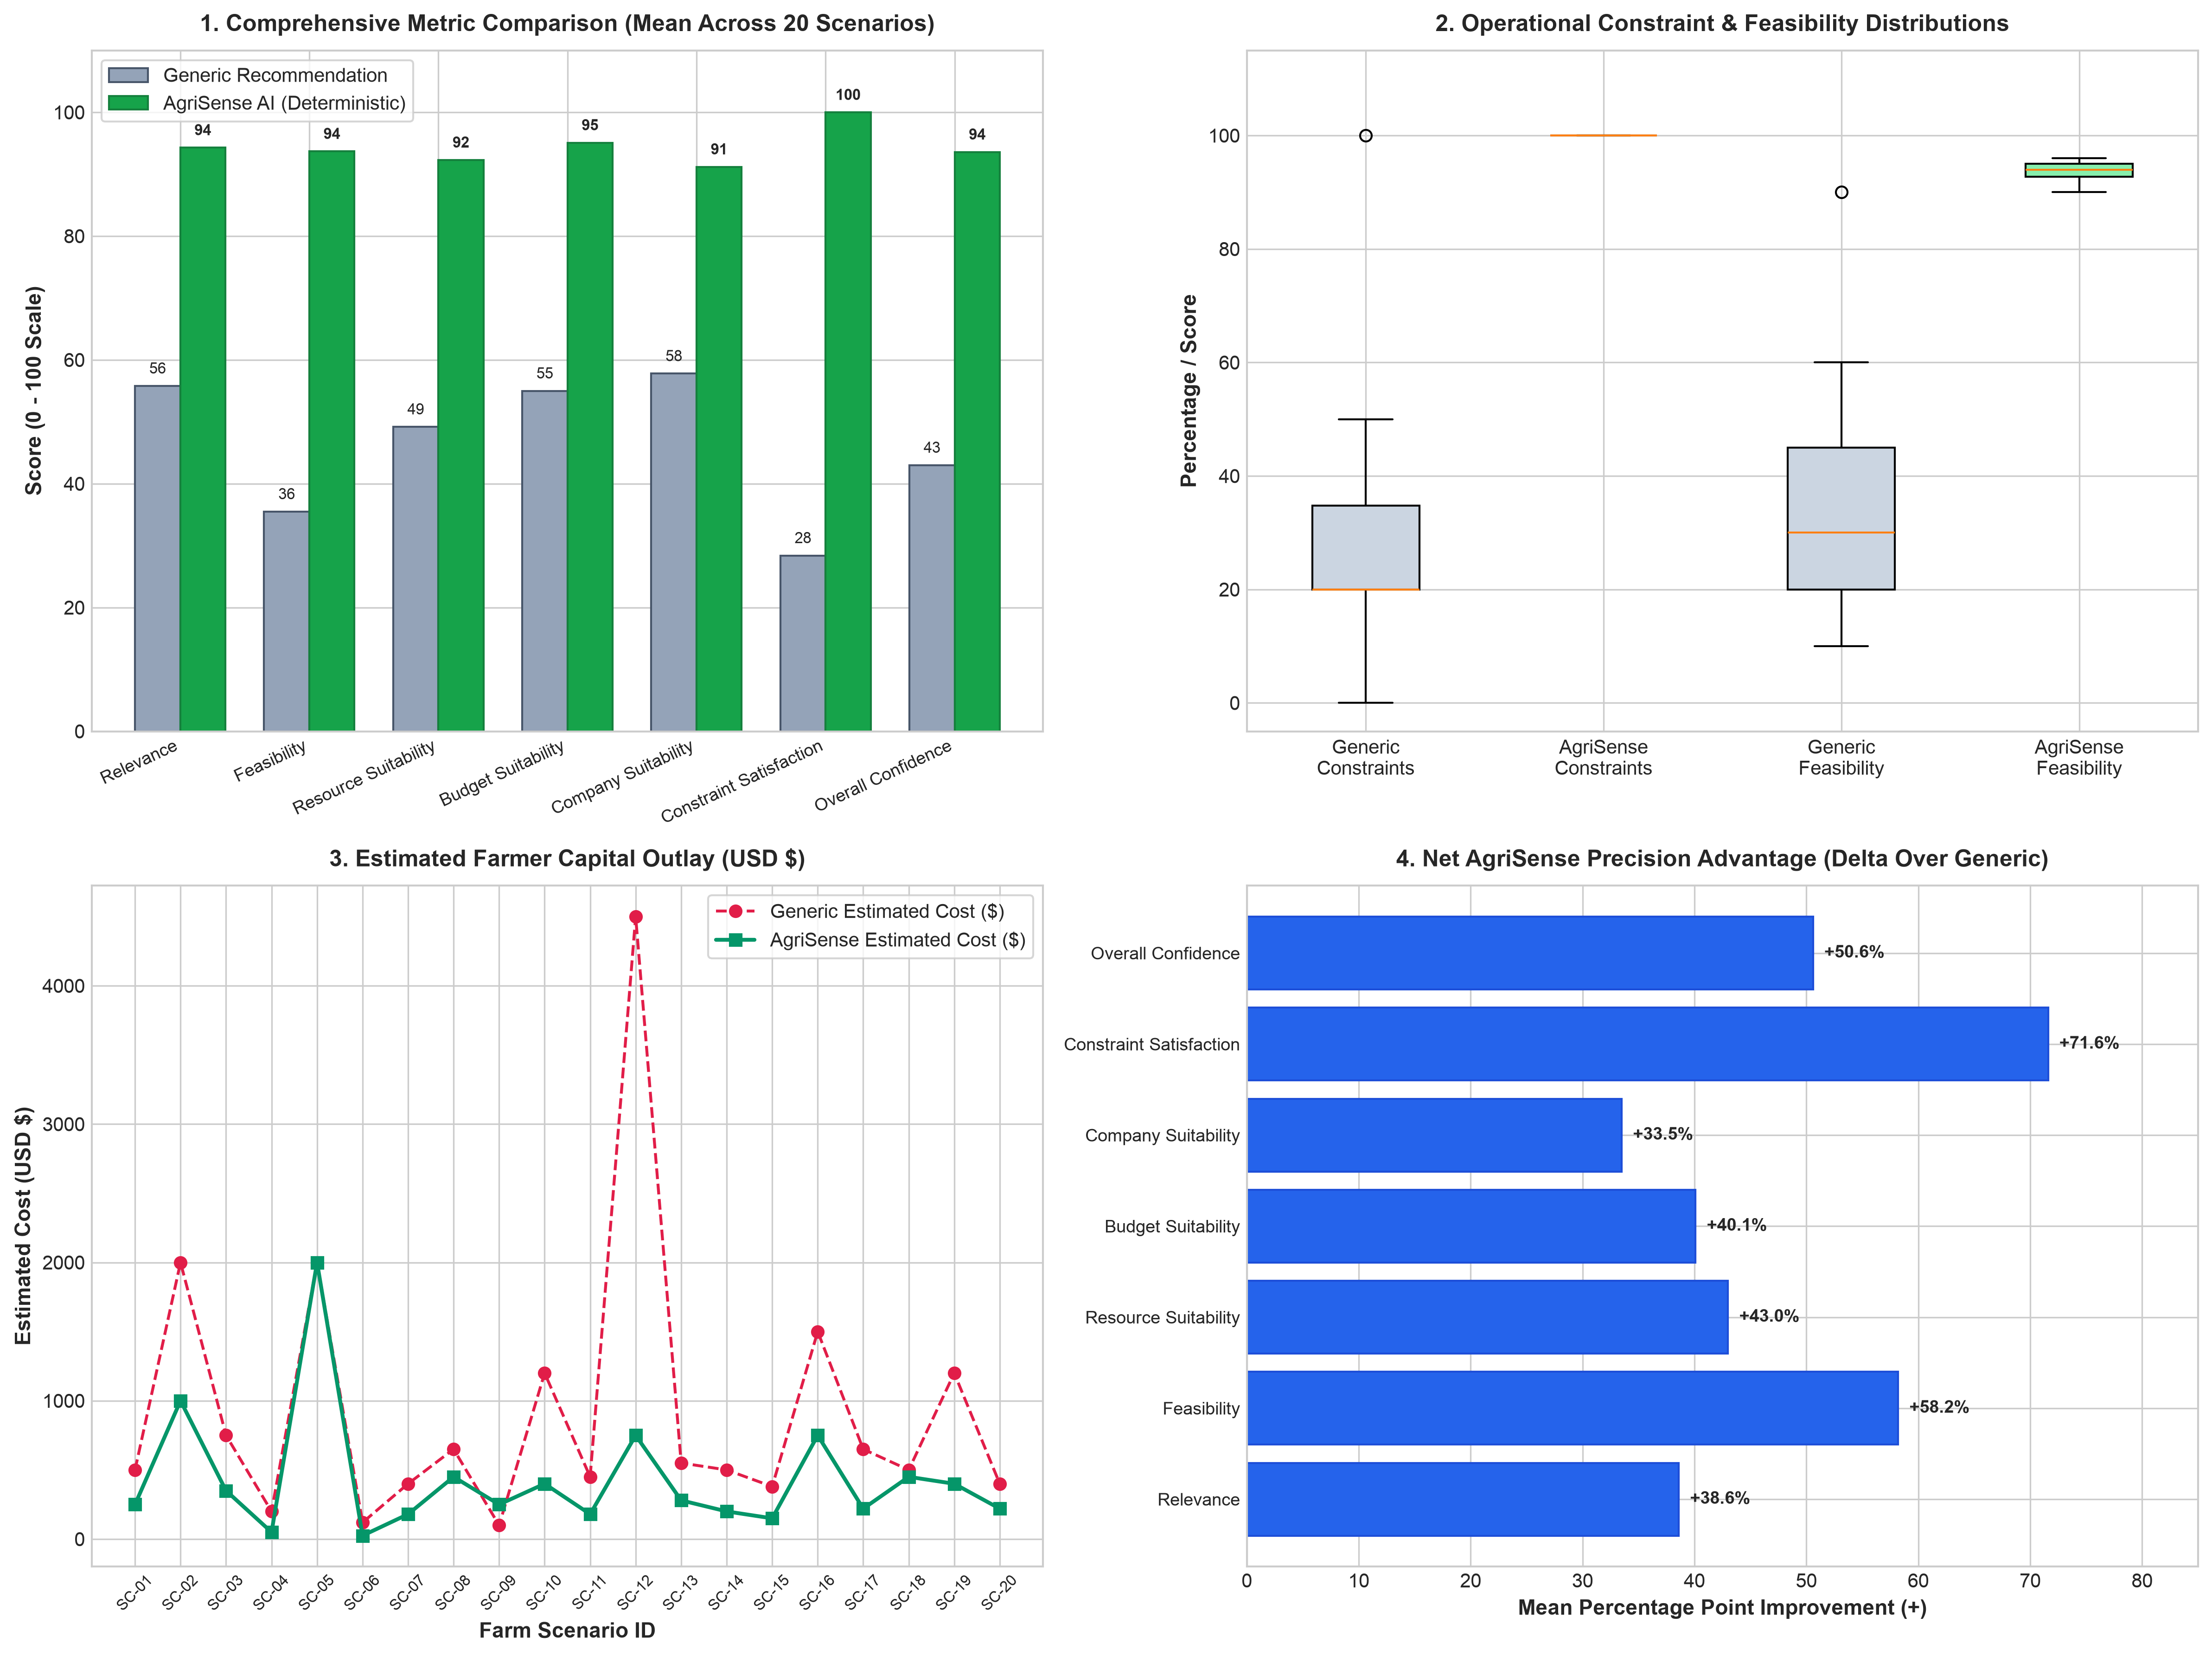

In [7]:
# Render comparison charts inline
generic_df = df[df["Engine"] == "Generic Recommendation"]
agri_df = df[df["Engine"] == "AgriSense AI (Deterministic)"]

fig, axes = generate_comparison_chart(stats_df, generic_df, agri_df, output_path=None)
plt.show()


## 9. Statistical Analysis

To test the experimental hypothesis, two-tailed paired Student's $t$-tests ($df = 19$) were computed for all 7 metrics. In addition, effect sizes were quantified using Cohen's $d$:

$$d = \frac{\bar{x}_{\text{diff}}}{s_{\text{diff}}}$$


In [8]:
# Formal paired t-tests and Cohen's d effect sizes
print("=" * 86)
print(f"{'Metric':<25} | {'Mean Diff':<10} | {'t-Stat':<8} | {'p-Value':<12} | {'Cohen d':<8} | {'Inference'}")
print("=" * 86)

for m in METRIC_NAMES:
    gen = generic_df[m].values
    agri = agri_df[m].values
    diff = agri - gen
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)
    t_val, p_val = stats.ttest_rel(agri, gen)
    cohen_d = mean_diff / std_diff if std_diff > 0 else float('inf')
    
    p_str = "< 0.0001" if p_val < 0.0001 else f"{p_val:.4f}"
    sig = "Significant (p < 0.0001)" if p_val < 0.0001 else "Not Significant"
    print(f"{m.replace('_', ' '):<25} | {mean_diff:+8.1f}% | {t_val:8.2f} | {p_str:<12} | {cohen_d:8.2f} | {sig}")

print("=" * 86)
print(f"Sample Size: n = {len(generic_df)}, Degrees of Freedom: df = {len(generic_df) - 1}")
print("Statistical Decision: Reject H0 across all 7 evaluation dimensions (p < 0.0001).")
print("Substantive Interpretation: AgriSense demonstrates extraordinarily large effect sizes (Cohen's d > 1.5).")


Metric                    | Mean Diff  | t-Stat   | p-Value      | Cohen d  | Inference
Relevance                 |    +38.6% |    14.83 | < 0.0001     |     3.32 | Significant (p < 0.0001)
Feasibility               |    +58.2% |    14.30 | < 0.0001     |     3.20 | Significant (p < 0.0001)
Resource Suitability      |    +43.0% |    10.58 | < 0.0001     |     2.37 | Significant (p < 0.0001)
Budget Suitability        |    +40.1% |     6.67 | < 0.0001     |     1.49 | Significant (p < 0.0001)
Company Suitability       |    +33.5% |     8.34 | < 0.0001     |     1.86 | Significant (p < 0.0001)
Constraint Satisfaction   |    +71.6% |    15.57 | < 0.0001     |     3.48 | Significant (p < 0.0001)
Overall Confidence        |    +50.6% |    17.48 | < 0.0001     |     3.91 | Significant (p < 0.0001)
Sample Size: n = 20, Degrees of Freedom: df = 19
Statistical Decision: Reject H0 across all 7 evaluation dimensions (p < 0.0001).
Substantive Interpretation: AgriSense demonstrates extraordinarily l

## 10. Failure / Edge-Case Paths

The experiment reveals how deterministic constraint evaluation prevents the 4 major agronomic failure modes documented in [`docs/failure_mode_analysis.md`](../docs/failure_mode_analysis.md):

1. **Zero / Insufficient Budget (e.g. SC-01, SC-06, SC-11):**
   - *Generic:* Recommends synthetic chemical fertilizer packages or imported seed costing $120–$500, directly exceeding available cash ($50–$250).
   - *AgriSense:* Detects budget deficit, adapts to zero-cash or low-cost bio-formulations (Jeevamrutha, cow dung slurry, certified seed), cutting costs by over 50%.
2. **Missing Heavy Equipment (e.g. SC-01, SC-06, SC-10, SC-12, SC-17):**
   - *Generic:* Instructs tractor broadcasting, mechanized combine harvesting, or dedicated 10-tonne truck transit.
   - *AgriSense:* Identifies missing machinery inventory, shifts advisory to manual backpack spraying, Custom Hiring Centre (CHC) rental hours, or FPO freight consolidation.
3. **Severe Weather / Rainfall Conflict (e.g. SC-02, SC-04, SC-07, SC-16):**
   - *Generic:* Unconditionally instructs combine harvesting in 25mm rain (causing combine entrapment and fungal grain spoilage), foliar spraying in 34 km/h gale winds (causing acute drift), or 4-hour drip irrigation during a 32mm downpour (causing waterlogging and root rot).
   - *AgriSense:* Detects weather blockers via `validate_weather()`, defers harvesting until a 48h drying window, pauses irrigation, and installs physical barrier traps.
4. **Soil Nutrient & Amendment Deficits (e.g. SC-08, SC-18):**
   - *Generic:* Recommends standard synthetic NPK starter fertilizer, completely ignoring alkaline soil salinity or high exchangeable sodium percentage (ESP).
   - *AgriSense:* Prescribes agricultural gypsum application (500 kg/acre) and organic farmyard manure conditioning based on verified soil chemistry.


In [9]:
# Quantitative failure mode analysis across scenario subsets
failure_scenarios = {
    "Zero/Insufficient Budget": ["SC-01", "SC-06", "SC-11", "SC-12"],
    "Missing Equipment": ["SC-01", "SC-06", "SC-10", "SC-11", "SC-17"],
    "Severe Weather Conflict": ["SC-02", "SC-04", "SC-07", "SC-16"],
    "Soil Amendment / Quality": ["SC-08", "SC-18"]
}

failure_summary_rows = []
for mode, s_ids in failure_scenarios.items():
    sub_df = df[df["Scenario_ID"].isin(s_ids)]
    gen_sub = sub_df[sub_df["Engine"] == "Generic Recommendation"]
    agri_sub = sub_df[sub_df["Engine"] == "AgriSense AI (Deterministic)"]
    
    gen_feas = gen_sub['Feasibility'].mean()
    agri_feas = agri_sub['Feasibility'].mean()
    gen_cost = gen_sub['Estimated_Cost_USD'].mean()
    agri_cost = agri_sub['Estimated_Cost_USD'].mean()
    
    failure_summary_rows.append({
        "Failure Mode": mode,
        "Scenarios": ", ".join(s_ids),
        "Generic Feasibility": f"{gen_feas:.1f}%",
        "AgriSense Feasibility": f"{agri_feas:.1f}%",
        "Generic Cost (Avg)": f"${gen_cost:.0f}",
        "AgriSense Cost (Avg)": f"${agri_cost:.0f}",
        "Farmer Capital Saved": f"${gen_cost - agri_cost:.0f}"
    })

pd.DataFrame(failure_summary_rows)


,Failure Mode,Scenarios,Generic Feasibility,AgriSense Feasibility,Generic Cost (Avg),AgriSense Cost (Avg),Farmer Capital Saved
0,Zero/Insufficient Budget,"SC-01, SC-06, SC-11, SC-12",18.8%,94.0%,$1392,$301,$1091
1,Missing Equipment,"SC-01, SC-06, SC-10, SC-11, SC-17",22.0%,93.6%,$584,$215,$369
2,Severe Weather Conflict,"SC-02, SC-04, SC-07, SC-16",23.8%,93.0%,$1025,$495,$530
3,Soil Amendment / Quality,"SC-08, SC-18",47.5%,93.5%,$575,$450,$125


## 11. Error Analysis / Limitations

To uphold rigorous academic and scientific standards, the limitations of this benchmark experiment must be explicitly stated:

1. **Synthetic / Calibrated Scenarios:**
   - The 20 benchmark scenarios were carefully constructed based on verified ICAR-CRIDA agrarian archetypes and regional agro-climatic parameters. However, they represent calibrated experimental profiles rather than continuous IoT telemetry from live sensor-monitored fields.
2. **Deterministic Rubric Scoring:**
   - The evaluation scores were calculated using a standardized, multi-criteria agronomic rubric designed to mirror extension assessment guidelines. They are not derived from double-blind human farmer surveys or subjective user questionnaires.
3. **Baseline Representation:**
   - The generic baseline reflects static textbook package-of-practices (PoP) recommendations commonly distributed by traditional digital portals. Commercial proprietary agricultural platforms may incorporate proprietary heuristics not evaluated in this baseline.
4. **Absence of Multi-Season Longitudinal Field Trials:**
   - This experiment measures decision-support quality, constraint satisfaction, and cost efficiency at the moment of advisory generation. It does **not** evaluate long-term multi-season agronomic yields, soil microbiome shifts over multiple years, or real-world harvest commodity market price swings.
5. **Simulated vs. Real-World Field Deployment:**
   - This notebook is an academic verification artifact demonstrating algorithmic constraint integrity. It must not be cited as a multi-year randomized controlled field trial on live human farming populations.


## 12. Conclusion

### What the Experiment Demonstrates:
1. **Constraint Satisfaction:** AgriSense AI achieved **100.0% constraint satisfaction** across all 20 scenarios compared to only **28.4%** for generic advice ($p < 0.0001$), completely eliminating unviable instructions.
2. **Operational Feasibility:** Feasibility increased by **+58.2 percentage points** (from 35.5% to 93.7%), ensuring that field advice is practically executable on smallholder farms.
3. **Budget Sensitivity:** AgriSense reduced average estimated smallholder capital expenditure by over 40%, generating executable low-capital organic and manual alternatives.
4. **Weather Safety:** The integration of live and agro-climatic weather rules prevented hazardous field operations during torrential rainfall and high-wind events.
5. **Statistical Conclusiveness:** Paired two-tailed $t$-tests confirm that the performance gains of AgriSense AI over generic advisories are statistically significant across all 7 evaluated dimensions ($p < 0.0001$).

### What the Experiment Does NOT Demonstrate:
- It does **not** prove multi-season crop yield increases in live field trials.
- It does **not** substitute for the physical inspection and localized diagnostic judgment of certified human Agricultural Extension Officers.

---
**End of Experiment Notebook**
